# Hyperparameter Tuning — Turnaround Time

## Objective

Improve the selected Random Forest model for Turnaround Time
prediction by searching for better hyperparameters.

The baseline Random Forest will be used as the reference model.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score



In [2]:
df = pd.read_csv("ml_ready.csv")

In [3]:
df.shape

(6583, 26)

In [4]:
X = df.drop(
    columns=[
        "Repair_Cost",
        "Turnaround_Time_Days",
        "Is_Delayed"
    ]
)

y = df["Turnaround_Time_Days"]

In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6583, 23)
y shape: (6583,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
print("X_train Shape" ,X_train.shape)
print("X_test Shape" , X_test.shape)

X_train Shape (5266, 23)
X_test Shape (1317, 23)


In [8]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

In [9]:
print("Numerical Features:", len(numerical_features))
print(numerical_features)

print("\nCategorical Features:", len(categorical_features))
print(categorical_features)

Numerical Features: 13
['Visit_Number', 'Vehicle_Age_at_Service', 'Battery_Age_at_Service', 'Battery_Health_at_Service', 'Expected_Part_ETA_Days', 'Active_Jobs_On_Arrival', 'Workshop_Utilization', 'Technician_Experience_Years', 'Repair_Complexity', 'Base_Labor_Hours', 'Technician_Efficiency', 'Effective_Labor_Hours', 'Expected_TAT_Days']

Categorical Features: 10
['Vehicle_Model', 'Battery_Replaced', 'Issue_Family', 'Exact_Issue', 'Parts_Required', 'Parts_Available', 'Part_Ordered', 'Day_Type', 'Warranty_Status', 'Warranty_Covered']


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [11]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [12]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [13]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

In [14]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['Visit_Number',
                                                                                'Vehicle_Age_at_Service',
                                                                                'Battery_Age_at_Service',
                                                                                'Battery_Health_at_Service',
                                                                                'Expected_Part_ETA_Days',
                                                                                'Active_Jobs_On_Arrival',
                                                                                'Workshop_Utilization',
                                                                                'Technician_Experience_Years',
                                                                                'Repair_Complexity',
                                                                                'Base_Labor_Ho...
                                                                                'Day_Type',
                                                                                'Warranty_Status',
                                                                                'Warranty_Covered'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                             20],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [15]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 10}


In [16]:
print("Best CV MAE:", -random_search.best_score_)

Best CV MAE: 0.31380369912535944


In [17]:
-random_search.best_score_

np.float64(0.31380369912535944)

In [18]:
best_tat_model = random_search.best_estimator_


In [19]:
y_pred_tat_tuned = best_tat_model.predict(X_test)

In [20]:
mae_tat_tuned = mean_absolute_error(
    y_test,
    y_pred_tat_tuned
)

rmse_tat_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tat_tuned
    )
)

r2_tat_tuned = r2_score(
    y_test,
    y_pred_tat_tuned
)

In [21]:
print(f"MAE  : {mae_tat_tuned:.2f}")
print(f"RMSE : {rmse_tat_tuned:.2f}")
print(f"R²   : {r2_tat_tuned:.3f}")

MAE  : 0.32
RMSE : 0.47
R²   : 0.922


In [22]:
import joblib

joblib.dump(
    best_tat_model,
    "tat_model.pkl"
)

['tat_model.pkl']

In [23]:
import os

print(os.path.exists("tat_model.pkl"))

True


In [24]:
import shap

In [25]:
best_tat_model = joblib.load("tat_model.pkl")

In [26]:
preprocessor_tat = best_tat_model.named_steps["preprocessor"]

rf_tat_model = best_tat_model.named_steps["model"]

In [27]:
X_test_tat_transformed = preprocessor_tat.transform(X_test)

In [28]:
if hasattr(X_test_tat_transformed, "toarray"):
    X_test_tat_transformed = X_test_tat_transformed.toarray()

X_test_tat_transformed = X_test_tat_transformed.astype(np.float64)

In [29]:
feature_names_tat = (
    preprocessor_tat.get_feature_names_out()
)

In [30]:
print(
    "Transformed features:",
    len(feature_names_tat)
)

Transformed features: 67


In [31]:
explainer_tat = shap.TreeExplainer(
    rf_tat_model
)

In [32]:
shap_values_tat = explainer_tat.shap_values(
    X_test_tat_transformed
)

In [33]:
print(shap_values_tat.shape)

(1317, 67)


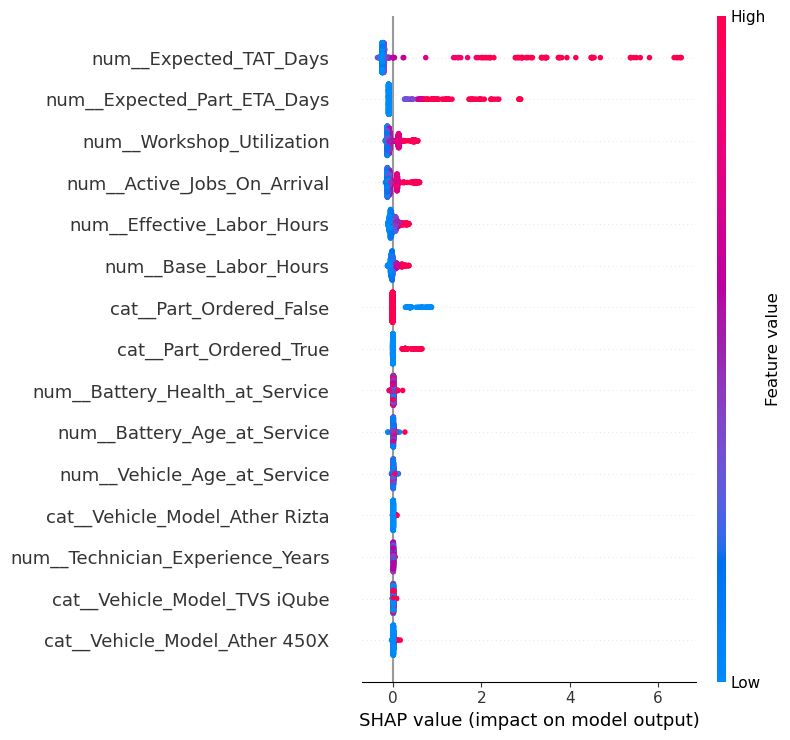

In [34]:
shap.summary_plot(
    shap_values_tat,
    X_test_tat_transformed,
    feature_names=feature_names_tat,
    max_display=15
)

## TAT Model Explainability — Key Findings

SHAP analysis shows that the strongest contributors to Turnaround Time
predictions are:

- Expected TAT
- Expected Part ETA
- Workshop Utilization
- Active Jobs on Arrival
- Effective Labor Hours
- Base Labor Hours

These features represent expected service duration, parts-related
constraints, workshop workload, and labor requirements.

### Important Modeling Assumption

Expected_TAT_Days is treated as a valid prediction-time feature because
it represents an estimate available before the service visit is
completed.

It must not be calculated using actual Turnaround_Time_Days or any
information that becomes available after service completion.

Therefore, its use depends on the actual timing of feature availability
in the production system.

In [35]:
row_index = 0

In [36]:
y_pred_tat_tuned = best_tat_model.predict(X_test)

In [37]:
actual_tat = y_test.iloc[row_index]
predicted_tat = y_pred_tat_tuned[row_index]

print(f"Actual TAT    : {actual_tat:.2f} days")
print(f"Predicted TAT : {predicted_tat:.2f} days")

Actual TAT    : 1.57 days
Predicted TAT : 0.87 days


In [38]:
X_test.iloc[row_index]

Visit_Number                                1
Vehicle_Model                       TVS iQube
Vehicle_Age_at_Service                   0.82
Battery_Age_at_Service                   0.58
Battery_Health_at_Service               97.39
Battery_Replaced                        False
Issue_Family                            Brake
Exact_Issue                    Brake Pad Wear
Parts_Required                           True
Parts_Available                          True
Part_Ordered                            False
Expected_Part_ETA_Days                      0
Active_Jobs_On_Arrival                     19
Workshop_Utilization                     0.95
Day_Type                              Weekend
Technician_Experience_Years                 2
Repair_Complexity                           2
Base_Labor_Hours                         1.94
Technician_Efficiency                    0.97
Effective_Labor_Hours                    1.88
Warranty_Status                          True
Warranty_Covered                  

In [39]:
row_shap_values_tat = shap_values_tat[row_index]

In [40]:
print(row_shap_values_tat.shape)

(67,)


In [41]:
local_tat_explanation = pd.DataFrame({
    "Feature": feature_names_tat,
    "SHAP_Value": row_shap_values_tat
})

local_tat_explanation["Abs_SHAP"] = (
    local_tat_explanation["SHAP_Value"].abs()
)

local_tat_explanation = local_tat_explanation.sort_values(
    "Abs_SHAP",
    ascending=False
)

local_tat_explanation.head(15)

,Feature,SHAP_Value,Abs_SHAP
12,num__Expected_TAT_Days,-0.244834,0.244834
6,num__Workshop_Utilization,0.108735,0.108735
4,num__Expected_Part_ETA_Days,-0.104206,0.104206
5,num__Active_Jobs_On_Arrival,0.072913,0.072913
9,num__Base_Labor_Hours,-0.027547,0.027547
11,num__Effective_Labor_Hours,0.015454,0.015454
59,cat__Part_Ordered_False,-0.014947,0.014947
3,num__Battery_Health_at_Service,0.012199,0.012199
60,cat__Part_Ordered_True,-0.012011,0.012011
34,cat__Exact_Issue_Brake Pad Wear,0.004333,0.004333


In [44]:
base_value_tat = np.asarray(
    explainer_tat.expected_value
).item()

shap_prediction_tat = (
    base_value_tat
    + row_shap_values_tat.sum()
)

print(
    f"SHAP reconstructed prediction: "
    f"{shap_prediction_tat:.2f} days"
)

print(
    f"Model prediction: "
    f"{predicted_tat:.2f} days"
)

SHAP reconstructed prediction: 0.87 days
Model prediction: 0.87 days


In [46]:
print(mae_tat_tuned)
print(rmse_tat_tuned)
print(r2_tat_tuned)

0.319257456695888
0.46651821733333065
0.9217425402356195


## Final TAT Model Performance

After hyperparameter tuning, the final Random Forest achieved:

- MAE: 0.32 days
- RMSE: 0.47 days
- R²: 0.922

Compared with the baseline Random Forest:

- MAE improved from 0.33 to 0.32 days
- RMSE improved from 0.48 to 0.47 days
- R² improved from 0.916 to 0.922

The final model explains approximately 92.2% of the variation in
Turnaround Time on the held-out test set.

An MAE of 0.32 days corresponds to approximately 7.7 hours of average
absolute prediction error.

In [47]:
import joblib

joblib.dump(
    best_tat_model,
    "tat_model.pkl"
)

['tat_model.pkl']

In [ ]:
import os

print(os.path.exists("tat_model.pkl"))